In [7]:
import pandas as pd
import faiss
from models.embedder import embed_query
from src.utils import load_image
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

In [8]:
df = pd.read_csv("data/metadata.csv")
index=faiss.read_index("data/index.faiss")
print(df.head(10))

                                image_path class_name
0  data/intel/seg_test\buildings\20057.jpg  buildings
1  data/intel/seg_test\buildings\20060.jpg  buildings
2  data/intel/seg_test\buildings\20061.jpg  buildings
3  data/intel/seg_test\buildings\20064.jpg  buildings
4  data/intel/seg_test\buildings\20073.jpg  buildings
5  data/intel/seg_test\buildings\20074.jpg  buildings
6  data/intel/seg_test\buildings\20078.jpg  buildings
7  data/intel/seg_test\buildings\20083.jpg  buildings
8  data/intel/seg_test\buildings\20094.jpg  buildings
9  data/intel/seg_test\buildings\20096.jpg  buildings


In [9]:
def get_query_vector(query):
    vec=embed_query(query)
    return np.array([vec]).astype("float32")


In [10]:
def search(query, k=5):
    q=get_query_vector(query)
    distances, indices = index.search(q, k)

    results=df.iloc[indices[0]].copy()
    results["distance"]=distances[0]
    return results


In [11]:
def show_results(query,results):
    plt.figure(figsize=(12,4))

    plt.subplot(1,len(results)+1,1)

    if isinstance(query, str) and os.path.exists(query):
        plt.imshow(Image.open(query))
        plt.title("Query Image")
    else:
        plt.text(0.5, 0.5, str(query), ha='center', va='center')
        plt.title("Query Text")
    plt.axis('off')

    #Results
    for i, row in enumerate(results.itertuples()):
        plt.subplot(1,len(results)+1,i+2)
        plt.imshow(Image.open(row.image_path))
        plt.title(f"{row.class_name}\n{row.distance:.2f}")
        plt.axis('off')
    plt.show()

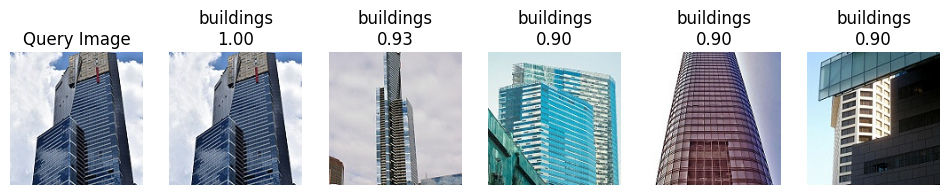

In [12]:
results = search("data/intel/seg_test/buildings/20057.jpg")
show_results("data/intel/seg_test/buildings/20057.jpg", results)

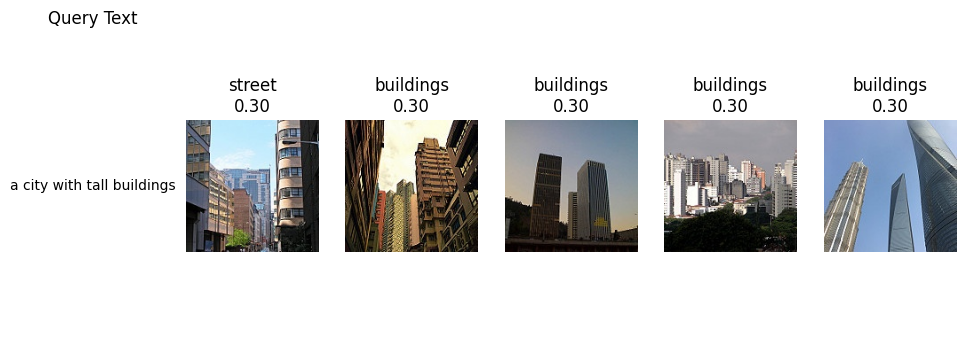

In [13]:
results = search("a city with tall buildings")
show_results("a city with tall buildings", results)

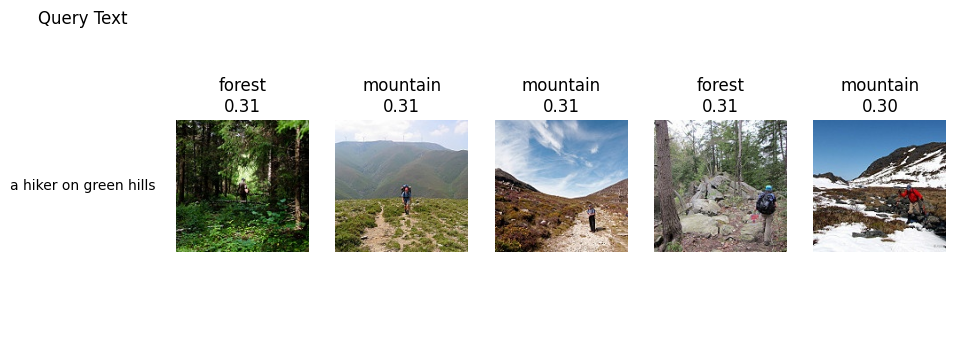

In [14]:
results = search("a hiker on green hills")
show_results("a hiker on green hills", results)

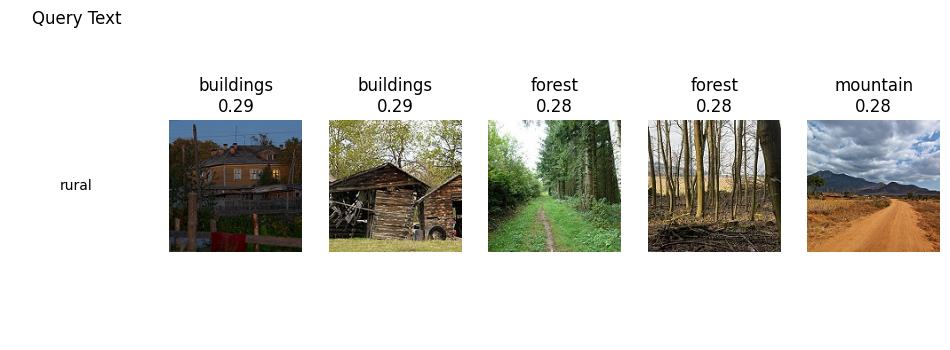

In [15]:
results = search("rural")
show_results("rural", results)

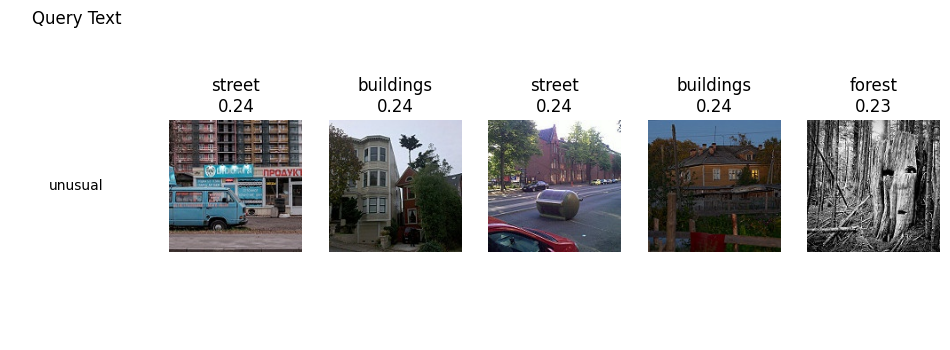

In [16]:
results = search("unusual")
show_results("unusual", results)

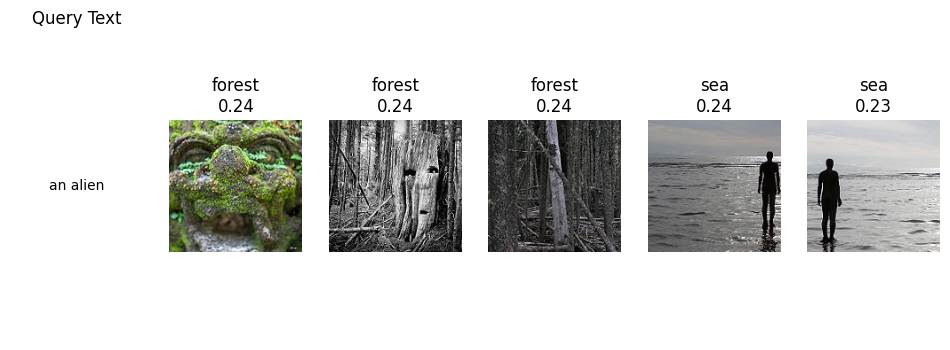

In [17]:
results = search("an alien")
show_results("an alien", results)

In [18]:
print(type(index))

<class 'faiss.swigfaiss_avx2.IndexFlatIP'>
